# <font color="yellow">**Limpieza de datos de DATASETS EPEN**</font>

## <font color="#07F0DB">1.- Unir datasets de manera general y crear la variable "entrenamiento"</font>


In [ ]:
#numpy - arreglos, matrices
#pandas - manejo de dataset
#matplotlib - graficas
#seabor - graficas
#glob - Busca archivos que coincidan con un patrón.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob as gl


In [ ]:
# Creando al dataset general
carpeta = sorted(gl.glob("/content/*_Trim_*.csv"))

datasets_list = []

for archivo in carpeta:
  dataset =  pd.read_csv(archivo)
  # *dataset.columns[:-1] selecciona todas las columnas excepto la última y a esta se le cambia el nombre
  dataset.columns = [*dataset.columns[:-1], 'factor_expansion']
  datasets_list.append(dataset)

entrenamiento = pd.concat(datasets_list, ignore_index=True)

##<font color="#07F0DB">2.- Verificar el Dataset e identificar columnas y campos vacíos</font>

* ANIO - Año de la encuesta
* MES - Mes de la encuesta
* CONGLOMERADO - Número del conglomerado
* MUESTRA - Nº de Sub Muestra
* SELVIV - Número de selección de la vivienda
* HOGAR - Hogar
* REGION - Región (1. Lima Metropolitana, 2. Resto urbano, 3. Rural)
* LLAVE_PANEL - Código del personal panel
* ESTRATO - Estrato geográfico (1 a 8 según tamaño de la UPM)
* C201 - 201. N° de orden (CÓDIGO DE PERSONA)
* C203 - 203. ¿Cuál es la relación de parentesco con el jefe del hogar?
* C204 - 204. ¿Es miembro del hogar?
* C205 - 205. ¿Se encuentra ausente del hogar 30 días o más?
* C206 - 206. ¿Está presente en el hogar 30 días o más?
* C207 - 207. Sexo
* C208 - 208. ¿Qué edad tiene en años cumplidos?
* C300n - Código de persona (Módulo de Empleo)
* NROINF - Código de informante (Módulo de Empleo)
* C301_DIA - 301. ¿Cuál es la fecha de su nacimiento? - Día
* C301_MES - 301. ¿Cuál es la fecha de su nacimiento? - Mes
* C301_ANIO - 301. ¿Cuál es la fecha de su nacimiento? - Año
* C303 - 303. ¿La semana pasada trabajó al menos 1 hora?
* C304 - 304. Aunque no trabajó la semana pasada, ¿tuvo algún empleo fijo al que próximamente volverá?
* C305 - 305. Aunque no trabajó la semana pasada, ¿tuvo algún negocio propio al que próximamente volverá?
* C306_1 - 306. Actividad semana pasada: ¿Trabajó en negocio propio o de un familiar?
* C306_2 - 306. Actividad semana pasada: ¿Ofreció algún servicio?
* C306_3 - 306. Actividad semana pasada: ¿Hizo algo en casa para vender?
* C306_4 - 306. Actividad semana pasada: ¿Vendió productos de belleza, ropa, joyas, entre otros?
* C306_5 - 306. Actividad semana pasada: ¿Realizó alguna labor artesanal?
* C306_6 - 306. Actividad semana pasada: ¿Hizo prácticas pagadas en un centro de trabajo?
* C306_7 - 306. Actividad semana pasada: ¿Trabajó para un hogar particular?
* C306_8 - 306. Actividad semana pasada: ¿Fabricó algún producto?
* C306_9 - 306. Actividad semana pasada: ¿Realizó labores remuneradas en la chacra o cuidado de animales?
* C306_10 - 306. Actividad semana pasada: ¿Ayudó a un familiar de su hogar, sin remuneración?
* C306_10A - 306. Actividad semana pasada: ¿Ayudó con el empleo de algún miembro de su hogar?
* C306_11 - 306. Actividad semana pasada: ¿Otra?
* C306A - 306A. ¿El informante es productor agrícola y/o pecuario?
* C308_COD - 308. ¿Cuál es la ocupación principal que desempeñó? - Código
* C309_COD - 309. ¿A qué se dedica el negocio/empresa en la que trabajó en su ocupación principal? - Código
* C310 - 310. Categoría de ocupación principal (empleador, independiente, empleado, etc.)
* C311 - 311. En su ocupación principal, ¿Ud. trabajó para:
* C312 - 312. ¿El negocio/empresa está registrado en SUNAT?
* C313 - 313. ¿El negocio/empresa lleva libros contables exigidos por la SUNAT?
* C317 - 317. Número de trabajadores en el negocio/empresa (rangos)
* C317A - 317A. Número exacto de trabajadores en el negocio/empresa
* C318_1 - 318. Horas trabajadas la semana pasada en ocupación principal - Domingo
* C318_2 - 318. Horas trabajadas la semana pasada en ocupación principal - Lunes
* C318_3 - 318. Horas trabajadas la semana pasada en ocupación principal - Martes
* C318_4 - 318. Horas trabajadas la semana pasada en ocupación principal - Miércoles
* C318_5 - 318. Horas trabajadas la semana pasada en ocupación principal - Jueves
* C318_6 - 318. Horas trabajadas la semana pasada en ocupación principal - Viernes
* C318_7 - 318. Horas trabajadas la semana pasada en ocupación principal - Sábado
* C318_T - 318. Total de horas trabajadas la semana pasada en ocupación principal
* C328_T - 328. Total de horas trabajadas la semana pasada en ocupación(es) secundaria(s)
* C330 - 330. En total, ¿cuántas horas trabajó la semana pasada?
* C331 - 331. Normalmente, ¿cuántas horas trabaja a la semana en todas sus ocupaciones?
* C333 - 333. La semana pasada, ¿quería trabajar más horas de las que normalmente trabaja?
* C334 - 334. La semana pasada, ¿estuvo disponible para trabajar más horas?
* P209H - ¿Tuvo la voluntad de trabajar más horas y además estuvo disponible para hacerlo?
* C335 - 335. La semana pasada, ¿estuvo Ud. buscando otro empleo? (Ocupados)
* C338 - 338. En su ocupación principal, ¿a Ud. le pagan: (frecuencia)?
* C339_1 - 339. Ingreso total en ocupación principal (dependiente) - Monto S/.
* C341_T - 341. Valor estimado total de pago en especies en ocupación principal (dependiente)
* C342 - 342. Ganancia neta en el mes anterior en ocupación principal (independiente)
* C344 - 344. Valor estimado de productos para consumo propio en mes anterior (independiente)
* C345_1 - 345. Ingreso total en ocupación(es) secundaria(s) (dependiente) - Monto S/.
* C347_T - 347. Valor estimado total de pago en especies en ocupación secundaria (dependiente)
* C348 - 348. Ganancia neta en el mes anterior en ocupación(es) secundaria(s) (independiente)
* C350 - 350. Valor estimado de productos para consumo propio en ocupación secundaria (independiente)
* C352 - 352. La semana pasada, ¿hizo algo para conseguir trabajo? (Desocupados)
* C353 - 353. ¿Qué estuvo haciendo la semana pasada? (Desocupados)
* C354 - 354. La semana pasada, ¿quería Ud. trabajar?
* C355 - 355. La semana pasada, ¿estuvo disponible para trabajar?
* C356 - 356. ¿Por qué no buscó trabajo?
* C357_I - 357. Gestión más importante para conseguir trabajo la semana pasada
* C358 - 358. ¿Cuántas semanas ha estado buscando trabajo, sin interrupciones?
* C359 - 359. ¿Ha trabajado antes?
* SEGURO1 - Sistema de seguro de salud al cual está afiliado
* C361_1 - 361. ¿Está afiliado a EsSalud?
* C361_2 - 361. ¿Está afiliado a seguro privado de salud?
* C361_3 - 361. ¿Está afiliado a Entidad Prestadora de Salud (EPS)?
* C361_4 - 361. ¿Está afiliado a seguro de FF.AA./Policiales?
* C361_5 - 361. ¿Está afiliado al Seguro Integral de Salud (SIS)?
* C361_6 - 361. ¿Está afiliado a seguro universitario?
* C361_7 - 361. ¿Está afiliado a seguro escolar privado?
* C361_8 - 361. ¿Está afiliado a otro seguro de salud?
* C362_1 - 362. ¿Quién aporta las cuotas? - EsSalud
* C362_2 - 362. ¿Quién aporta las cuotas? - Seguro privado de salud
* C362_3 - 362. ¿Quién aporta las cuotas? - Entidad Prestadora de Salud
* C362_4 - 362. ¿Quién aporta las cuotas? - Seguro FF.AA./Policiales
* C362_5 - 362. ¿Quién aporta las cuotas? - Seguro Integral de Salud (SIS)
* C362_6 - 362. ¿Quién aporta las cuotas? - Seguro universitario
* C362_7 - 362. ¿Quién aporta las cuotas? - Seguro escolar privado
* C362_8 - 362. ¿Quién aporta las cuotas? - Otro seguro
* C364_1 - 364. ¿Está afiliado al Sistema Privado de Pensiones (AFP)?
* C364_2 - 364. ¿Está afiliado al Sistema Nacional de Pensiones Ley 19990?
* C364_3 - 364. ¿Está afiliado al Sistema Nacional de Pensiones Ley 20530 (Cédula Viva)?
* C364_4 - 364. ¿Está afiliado a otro sistema de pensiones?
* C365_1 - 365. ¿Quién aporta las cuotas? - AFP
* C365_2 - 365. ¿Quién aporta las cuotas? - SNP Ley 19990
* C365_3 - 365. ¿Quién aporta las cuotas? - SNP Ley 20530
* C365_4 - 365. ¿Quién aporta las cuotas? - Otro sistema de pensiones
* C366 - 366. Último nivel de estudios aprobado
* C366_1 - 366. Último año de estudios aprobado
* C366_2 - 366. Último grado de estudios aprobado
* C375_1 - 375. Limitación permanente para moverse o caminar / usar brazos o piernas
* C375_2 - 375. Limitación permanente para ver (aun usando anteojos)
* C375_3 - 375. Limitación permanente para hablar o comunicarse
* C375_4 - 375. Limitación permanente para oír (aun usando audífonos)
* C375_5 - 375. Limitación permanente para entender o aprender
* C375_6 - 375. Limitación permanente para relacionarse con los demás
* C376 - 376. Idioma o lengua materna aprendida en la niñez
* C377 - 377. Autoidentificación étnica por costumbres y antepasados
* OCUP300 - Nivel de ocupación / Condición de actividad (ocupado, desocupado, inactivo)
* I339_1 - Ingreso mensual monetario de la actividad principal (dependiente)
* D341_T - Ingreso mensual en especies de la actividad principal (dependiente, valorizado)
* I342 - Ingreso mensual monetario de la actividad principal (independiente)
* D344 - Ingreso mensual en especies de la actividad principal (independiente, valorizado)
* I345_1 - Ingreso mensual monetario de la actividad secundaria (dependiente)
* I348 - Ingreso mensual monetario de la actividad secundaria (independiente)
* D347_T - Ingreso mensual en especies de la actividad secundaria (dependiente, valorizado)
* D350 - Ingreso mensual en especies de la actividad secundaria (independiente, valorizado)
* D351_T - (Mensual) En los últimos 12 meses, recibió algún dinero: Total
* INGTOT - Ingresos totales
* INGTOTP - Ingreso principal mensual
* INGTRABW - Ingreso mensual de ocupación principal y secundaria con ingresos extraordinarios
* RESIDENT - Residente habitual
* whoraT - Hora total de los ocupados
* factor_expansion - Agrupación de datos trimestrales para el cálculo de empleo


In [ ]:
# Verificar el dataset
entrenamiento.head(900)

,ANIO,MES,CONGLOMERADO,MUESTRA,SELVIV,HOGAR,REGION,LLAVE_PANEL,ESTRATO,C201,...,I345_1,I348,D347_T,D350,D351_T,INGTOT,INGTOTP,ingtrabw,RESIDENT,factor_expansion
0,2025,1,18325,1,11,1,1,202501183251001111,1.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,355.262372
1,2025,1,18325,1,15,1,1,202501183251001511,1.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,355.262372
2,2025,1,18338,1,43,1,1,202501183381004311,1.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,312.399192
3,2025,1,18338,1,44,1,1,202501183381004411,1.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,346.503640
4,2025,1,18411,1,56,1,1,202501184111005611,1.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,326.591133
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,2025,5,49391,1,34,1,1,202402493911003413,1.0,3,...,NaN,NaN,NaN,NaN,NaN,854.0,854.0,854.0,1,415.744858
896,2025,5,49391,1,34,1,1,202402493911003414,1.0,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
897,2025,5,49391,1,34,1,1,202402493911003415,1.0,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,346.677726
898,2025,5,49391,1,32,1,1,202402493911003211,1.0,1,...,NaN,NaN,NaN,NaN,NaN,800.0,800.0,800.0,1,415.744858


In [ ]:
# Conocer campos nulos
entrenamiento.isnull()

,ANIO,MES,CONGLOMERADO,MUESTRA,SELVIV,HOGAR,REGION,LLAVE_PANEL,ESTRATO,C201,...,I345_1,I348,D347_T,D350,D351_T,INGTOT,INGTOTP,ingtrabw,RESIDENT,factor_expansion
0,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,False
4,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,True
1796,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,False,False,False,False,False
1797,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,False,False,False,False,False
1798,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,True


<Axes: >

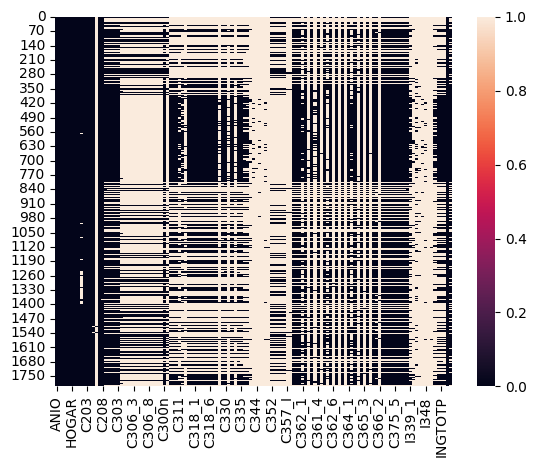

In [ ]:
# Ver graficos de valores en blanco
sns.heatmap(entrenamiento.isnull())

In [ ]:
# Columnas con valores nulos
col_nulos = []

for col in entrenamiento.columns:
    if entrenamiento[col].isnull().sum() > 0:
        col_nulos.append(col)

print(col_nulos)

['ESTRATO', 'C205', 'C206', 'C208', 'NROINF', 'C301_DIA', 'C301_MES', 'C301_ANIO', 'C303', 'C304', 'C305', 'C306_1', 'C306_2', 'C306_3', 'C306_4', 'C306_5', 'C306_6', 'C306_7', 'C306_8', 'C306_9', 'C306_10', 'C306_10A', 'C306_11', 'C300n', 'C306A', 'C308_COD', 'C309_COD', 'C310', 'C311', 'C312', 'C313', 'C317', 'C317A', 'C318_1', 'C318_2', 'C318_3', 'C318_4', 'C318_5', 'C318_6', 'C318_7', 'C318_T', 'C328_T', 'whoraT', 'C330', 'C331', 'C333', 'C334', 'P209H', 'C335', 'C338', 'C339_1', 'C341_T', 'C342', 'C344', 'C345_1', 'C347_T', 'C348', 'C350', 'C352', 'C353', 'C354', 'C355', 'C356', 'C357_I', 'C358', 'C359', 'SEGURO1', 'C361_1', 'C362_1', 'C361_2', 'C362_2', 'C361_3', 'C362_3', 'C361_4', 'C362_4', 'C361_5', 'C362_5', 'C361_6', 'C362_6', 'C361_7', 'C362_7', 'C361_8', 'C362_8', 'C364_1', 'C365_1', 'C364_2', 'C365_2', 'C364_3', 'C365_3', 'C364_4', 'C365_4', 'C366', 'C366_1', 'C366_2', 'C375_1', 'C375_2', 'C375_3', 'C375_4', 'C375_5', 'C375_6', 'C376', 'C377', 'OCUP300', 'I339_1', 'D341_T

###**<font color="#EFC05B">HEATMAP de Valores Nulos</font>**

/tmp/ipykernel_1825/2306939628.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(resultados_ordenado.values()), y=list(resultados_ordenado.keys()), palette='Reds_r')


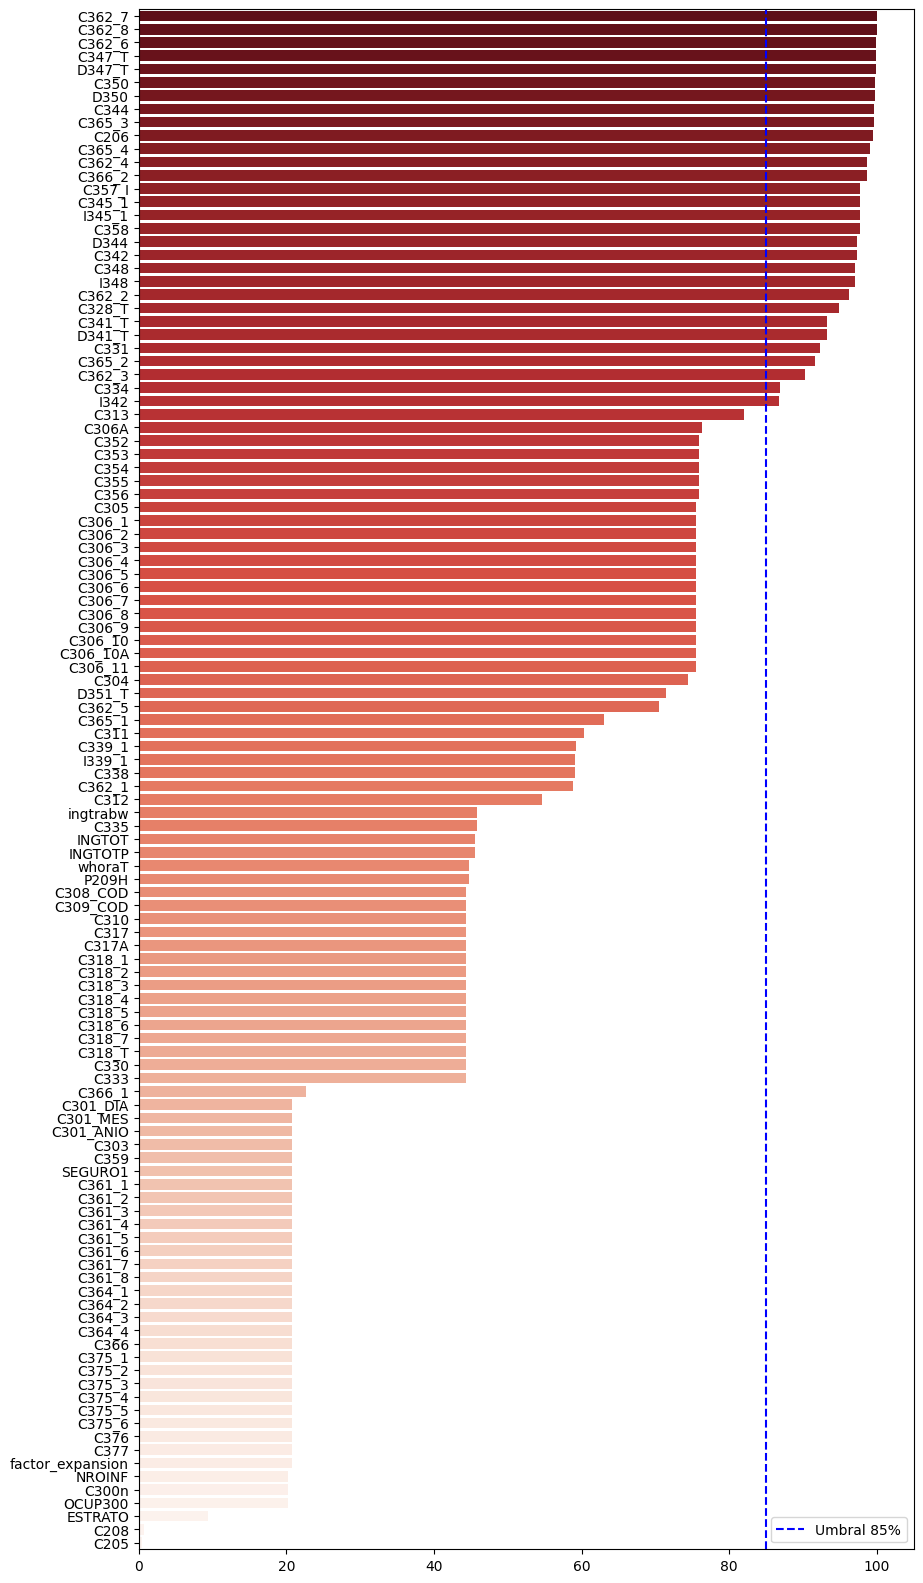

In [ ]:
# Verificar el porcentaje de valores nulos en las columnas con valores nulos
resultados = {}

for col in entrenamiento.columns:
    nulos = entrenamiento[col].isnull().sum()
    if nulos > 0:
        resultados[col] = (nulos / len(entrenamiento)) * 100

# Ordenar por porcentaje de mayor a menor
resultados_ordenado = {}

for col in sorted(resultados, key=resultados.get, reverse=True):
    resultados_ordenado[col] = resultados[col]

# Grafico
plt.figure(figsize=(10, 20))
sns.barplot(x=list(resultados_ordenado.values()), y=list(resultados_ordenado.keys()), palette='Reds_r')
plt.axvline(x=85, color='blue', linestyle='--', label='Umbral 85%')
plt.legend()
plt.show()


##<font color="#07F0DB">3.- Eliminamos las columnas vacias al 85%</font>

In [ ]:
# Eliminar columnas con más del 85% de nulos
# Primero identificamos las columnas a eliminar
columnas_eliminadas = []

for col in entrenamiento.columns:
    nulos = entrenamiento[col].isnull().sum()
    porcentaje = (nulos / len(entrenamiento)) * 100
    if porcentaje > 85:
        columnas_eliminadas.append(col)

# Luego las eliminas todas de una vez
entrenamiento.drop(columnas_eliminadas, axis=1, inplace=True)

print(f"Columnas eliminadas: {len(columnas_eliminadas)}")
print(f"Columnas restantes: {entrenamiento.shape[1]}")


Columnas eliminadas: 30
Columnas restantes: 99


<Axes: >

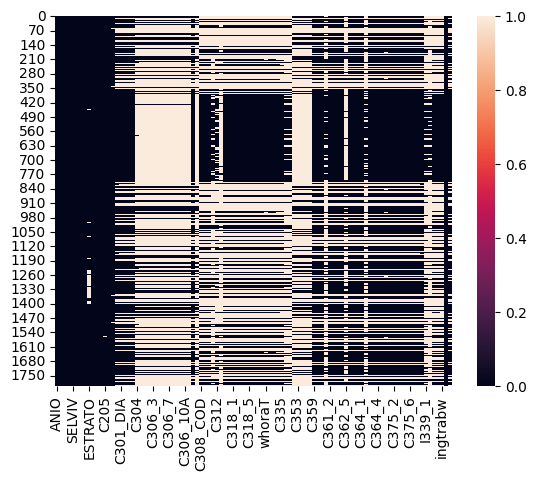

In [ ]:
# Resultado de eliminar columnas innecesarias
sns.heatmap(entrenamiento.isnull())

In [ ]:
# Verificar el porcentaje de valores nulos en las columnas con valores nulos
resultados = []

for col in entrenamiento.columns:
    nulos = entrenamiento[col].isnull().sum()
    if nulos > 0:
        porcentaje = (nulos / len(entrenamiento)) * 100
        resultados.append((porcentaje, col))

resultados.sort(reverse= True)

for porcentaje, col in resultados:
    print(f"{col}: ({round(porcentaje,2)}%)")

C313: (82.0%)
C306A: (76.33%)
C356: (75.89%)
C355: (75.89%)
C354: (75.89%)
C353: (75.89%)
C352: (75.89%)
C306_9: (75.56%)
C306_8: (75.56%)
C306_7: (75.56%)
C306_6: (75.56%)
C306_5: (75.56%)
C306_4: (75.56%)
C306_3: (75.56%)
C306_2: (75.56%)
C306_11: (75.56%)
C306_10A: (75.56%)
C306_10: (75.56%)
C306_1: (75.56%)
C305: (75.56%)
C304: (74.39%)
D351_T: (71.39%)
C362_5: (70.44%)
C365_1: (63.06%)
C311: (60.28%)
C339_1: (59.22%)
I339_1: (59.11%)
C338: (59.06%)
C362_1: (58.83%)
C312: (54.61%)
ingtrabw: (45.83%)
C335: (45.78%)
INGTOTP: (45.5%)
INGTOT: (45.5%)
whoraT: (44.78%)
P209H: (44.78%)
C333: (44.39%)
C330: (44.39%)
C318_T: (44.39%)
C318_7: (44.39%)
C318_6: (44.39%)
C318_5: (44.39%)
C318_4: (44.39%)
C318_3: (44.39%)
C318_2: (44.39%)
C318_1: (44.39%)
C317A: (44.39%)
C317: (44.39%)
C310: (44.39%)
C309_COD: (44.39%)
C308_COD: (44.39%)
C366_1: (22.61%)
factor_expansion: (20.72%)
SEGURO1: (20.72%)
C377: (20.72%)
C376: (20.72%)
C375_6: (20.72%)
C375_5: (20.72%)
C375_4: (20.72%)
C375_3: (20.72%)


##<font color="#07F0DB">4.- Eliminar colummnas sin relación a nuestro a dato a analizar</font>

El dato que se analizara sera ingreso

In [ ]:
# Filtrar solo personas ocupadas con ingreso
entrenamiento = entrenamiento[entrenamiento['OCUP300'] == 1]
entrenamiento = entrenamiento[entrenamiento['INGTOT'].notnull()]

print("Filas tras filtrar ocupados: ", len(entrenamiento))

Filas tras filtrar ocupados:  981


In [ ]:
columnas_innecesarias = [
    # Códigos administrativos de la encuesta (no predicen ingreso)
    'ANIO', 'MES', 'CONGLOMERADO', 'MUESTRA', 'SELVIV', 'HOGAR',
    'LLAVE_PANEL', 'C201', 'C203', 'C204', 'C206',
    'C300n', 'NROINF',

    # Fecha de nacimiento (tenemos edad en C208)
    'C301_DIA', 'C301_MES', 'C301_ANIO',

    # Solo para quienes NO trabajaron
    'C313', 'C306A', 'C304', 'C305',
    'C306_1', 'C306_2', 'C306_3', 'C306_4', 'C306_5',
    'C306_6', 'C306_7', 'C306_8', 'C306_9', 'C306_10',
    'C306_10A', 'C306_11',

    # Solo para desocupados
    'C352', 'C353', 'C354', 'C355', 'C356',

    # Códigos de ocupación (muy específicos, no generalizan)
    'C309_COD', 'C308_COD',

    # Número exacto de trabajadores (tenemos rango en C317)
    'C317A',

    # Año de estudios (tenemos nivel en C366)
    'C366_1',

    # Ingresos redundantes con INGTOT
    'D351_T', 'ingtrabw', 'INGTOTP',
    'C339_1', 'I339_1',

    # Quién paga seguros (no predice ingreso)
    'C362_5', 'C365_1', 'C362_1',

    # Seguros específicos con muy pocos afiliados
    'C361_2', 'C361_3', 'C361_4',
    'C361_6', 'C361_7', 'C361_8',
    'C364_2', 'C364_3', 'C364_4',

    # Horas por día individual (tenemos total en C318_T y whoraT)
    'C318_1', 'C318_2', 'C318_3',
    'C318_4', 'C318_5', 'C318_6', 'C318_7',

    # No relevantes para predecir ingreso
    'C303',    # ya filtramos ocupados
    'C330',    # horas normales semanales
    'C333',    # quería trabajar más horas
    'P209H',   # disponible para trabajar más
    'C335',    # buscó otro trabajo
    'OCUP300', # ya filtramos ocupados
    'RESIDENT',# residente habitual
    'factor_expansion', # peso estadístico, no predice ingreso
]

entrenamiento = entrenamiento.drop(columnas_innecesarias, axis=1, errors='ignore')
print(f"Columnas restantes: {entrenamiento.shape[1]}")

Columnas restantes: 27


<Axes: >

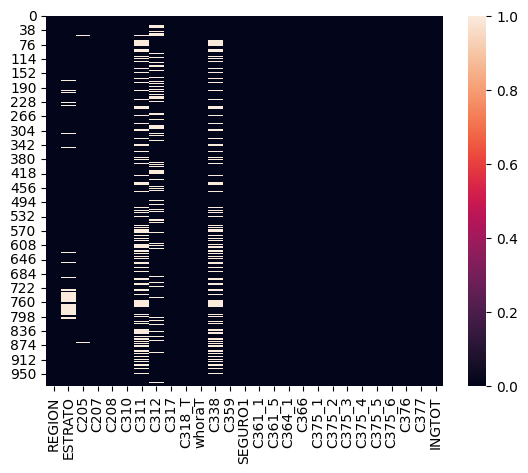

In [ ]:
# Resultado de eliminar columnas innecesarias
entrenamiento = entrenamiento.reset_index(drop=True)
sns.heatmap(entrenamiento.isnull())

In [ ]:
# Verificar el porcentaje de valores nulos en las columnas con valores nulos
resultados = []

for col in entrenamiento.columns:
    nulos = entrenamiento[col].isnull().sum()
    if nulos > 0:
        porcentaje = (nulos / len(entrenamiento)) * 100
        resultados.append((porcentaje, col))

resultados.sort(reverse= True)

for porcentaje, col in resultados:
    print(f"{col}: ({round(porcentaje,2)}%)")

C311: (27.22%)
C338: (24.97%)
C312: (18.65%)
ESTRATO: (8.97%)
C205: (0.31%)


##<font color="#07F0DB">5.- Imputación</font>

###<font color="#BAACDE">**ViolinPlot**</font>

/tmp/ipykernel_753/2683124410.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='C311', y='INGTOT', data=entrenamiento, palette='muted')


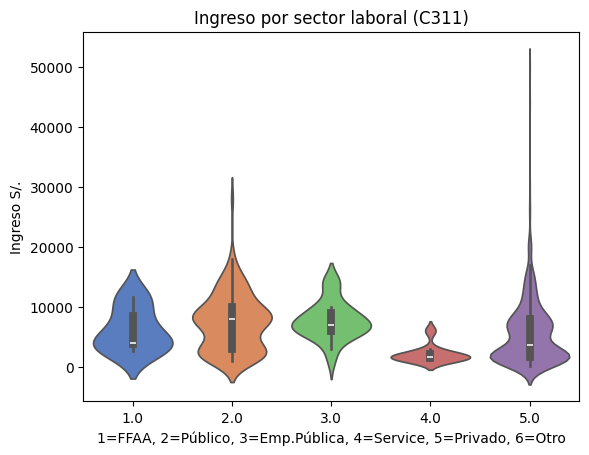

In [ ]:
# Grafico violin C311 vs INGTOT
sns.violinplot(x='C311', y='INGTOT', data=entrenamiento, palette='muted')
plt.title('Ingreso por sector laboral (C311)')
plt.xlabel('1=FFAA, 2=Público, 3=Emp.Pública, 4=Service, 5=Privado, 6=Otro')
plt.ylabel('Ingreso S/.')
plt.show()

###<font color="#BAACDE">**BarPlot**</font>

/tmp/ipykernel_1825/134248482.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='C338', y='INGTOT', data=entrenamiento, palette='Blues')


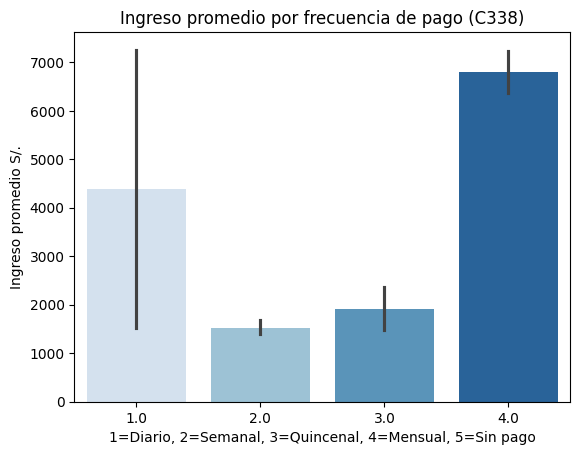

In [ ]:
# C338 - Frecuencia de pago vs INGTOT
sns.barplot(x='C338', y='INGTOT', data=entrenamiento, palette='Blues')
plt.title('Ingreso promedio por frecuencia de pago (C338)')
plt.xlabel('1=Diario, 2=Semanal, 3=Quincenal, 4=Mensual, 5=Sin pago')
plt.ylabel('Ingreso promedio S/.')
plt.show()

###<font color="#BAACDE">**PointPlot**</font>

/tmp/ipykernel_1825/431691702.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(x='C312', y='INGTOT', data=entrenamiento, palette='Reds')


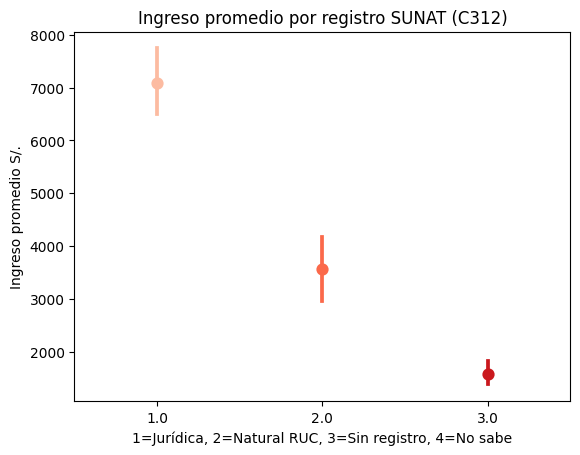

In [ ]:
# C312 - Registro SUNAT vs INGTOT
sns.pointplot(x='C312', y='INGTOT', data=entrenamiento, palette='Reds')
plt.title('Ingreso promedio por registro SUNAT (C312)')
plt.xlabel('1=Jurídica, 2=Natural RUC, 3=Sin registro, 4=No sabe')
plt.ylabel('Ingreso promedio S/.')
plt.show()

###<font color="#BAACDE">**BoxenPlot**</font>

/tmp/ipykernel_1825/552946284.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='ESTRATO', y='INGTOT', data=entrenamiento, palette='coolwarm')


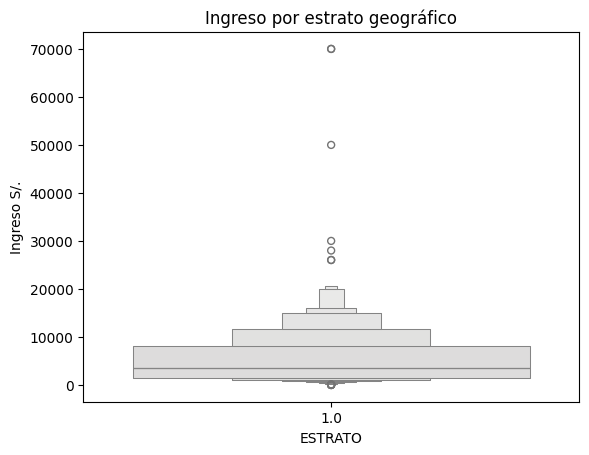

In [ ]:
# ESTRATO vs INGTOT
sns.boxenplot(x='ESTRATO', y='INGTOT', data=entrenamiento, palette='coolwarm')
plt.title('Ingreso por estrato geográfico')
plt.ylabel('Ingreso S/.')
plt.show()

###<font color="#BAACDE">**Boxplot**</font>

/tmp/ipykernel_1825/2175203935.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='C205', y='INGTOT', data=entrenamiento, palette=['#FF69B4', '#1E90FF'])
/tmp/ipykernel_1825/2175203935.py:1: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(x='C205', y='INGTOT', data=entrenamiento, palette=['#FF69B4', '#1E90FF'])


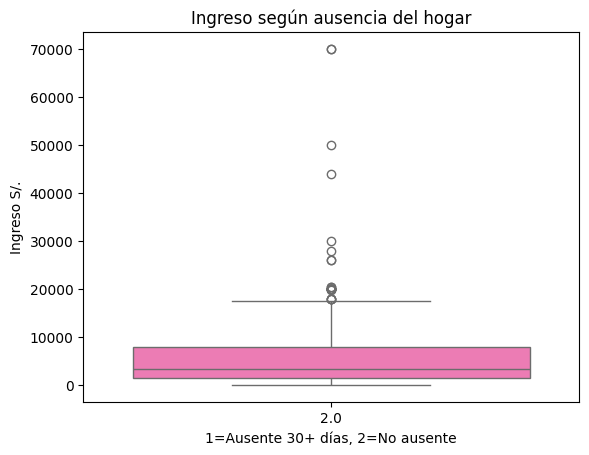

In [ ]:
sns.boxplot(x='C205', y='INGTOT', data=entrenamiento, palette=['#FF69B4', '#1E90FF'])
plt.title('Ingreso según ausencia del hogar')
plt.xlabel('1=Ausente 30+ días, 2=No ausente')
plt.ylabel('Ingreso S/.')
plt.show()

In [ ]:
# Creando función para rellenar el dataset
def dataset_moda(df, columnas):
    for col in columnas:
        moda = df[col].mode()[0]
        df[col] = df[col].fillna(moda)
    return df

In [ ]:
columnas_imputar = ['C311', 'C338', 'C312', 'ESTRATO', 'C205']
entrenamiento = dataset_moda(entrenamiento, columnas_imputar)

##<font color="#07F0DB">6.- Resultado Final</font>

<Axes: >

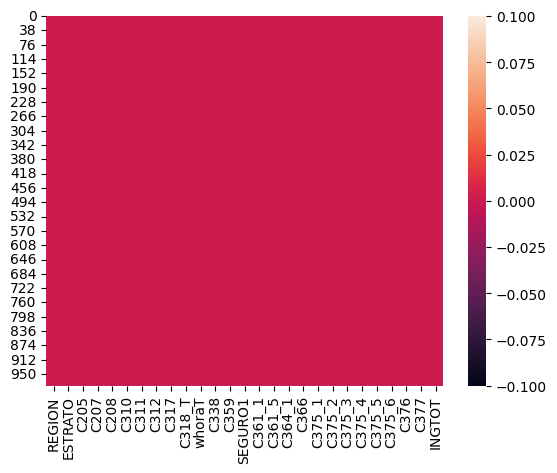

In [ ]:
sns.heatmap(entrenamiento.isnull())

##<font color="#07F0DB">7.- Entrenamiento del Dataset</font>

In [ ]:
# Librerías para dividir el dataset en entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Modelo Random Forest para regresión
from sklearn.ensemble import RandomForestRegressor

# Métricas para evaluar el desempeño del modelo
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

# Librerías para cálculos numéricos y visualización
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# La variable objetivo será el ingreso total de la persona
y = entrenamiento["INGTOT"]

# Se eliminan las columnas que no deben utilizarse para entrenar el modelo. INGTOT es la variable que queremos predecir, por lo tanto no puede formar parte de las variables predictoras.
X = entrenamiento.drop(columns=["INGTOT"])

# Mostrar la cantidad de variables predictoras
print(f"Número de variables predictoras: {X.shape[1]}")

# Mostrar la cantidad de registros
print(f"Número de registros: {X.shape[0]}")

# Verificar las dimensiones de X e y
print("\nDimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

Número de variables predictoras: 26
Número de registros: 981

Dimensión de X: (981, 26)
Dimensión de y: (981,)


In [ ]:
# Se divide el dataset en dos partes:
# 80% para entrenar el modelo
# 20% para evaluar su desempeño

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Mostrar las dimensiones de cada conjunto
print("Conjunto de entrenamiento (X_train):", X_train.shape)
print("Conjunto de prueba (X_test):", X_test.shape)

print("\nVariable objetivo entrenamiento (y_train):", y_train.shape)
print("Variable objetivo prueba (y_test):", y_test.shape)

Conjunto de entrenamiento (X_train): (784, 26)
Conjunto de prueba (X_test): (197, 26)

Variable objetivo entrenamiento (y_train): (784,)
Variable objetivo prueba (y_test): (197,)


In [ ]:
# Se crea el modelo Random Forest para problemas de regresión.
# Se utilizarán 100 árboles de decisión para realizar la predicción.

modelo_rf = RandomForestRegressor(
    n_estimators=100,      # Número de árboles del bosque
    random_state=42,       # Permite reproducir siempre los mismos resultados
    n_jobs=-1              # Utiliza todos los núcleos del procesador
)

# Entrenamiento del modelo utilizando los datos de entrenamiento
modelo_rf.fit(X_train, y_train)

print("Modelo Random Forest entrenado correctamente.")

Modelo Random Forest entrenado correctamente.


##<font color="#07F0DB">8.- Modelo de Pruebas</font>

In [ ]:
# El modelo realiza predicciones utilizando los datos de prueba
y_pred = modelo_rf.predict(X_test)

print("Predicciones realizadas correctamente.")

# Mostrar las primeras predicciones obtenidas
print("\nPrimeras 10 predicciones:")
print(y_pred[:10])

Predicciones realizadas correctamente.

Primeras 10 predicciones:
[ 2064.26       11755.26666667  1585.7         2491.02
  1990.6         1524.4         8672.29        4116.26
  2567.12        8640.56      ]


In [ ]:
# Calcular el Error Absoluto Medio (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Calcular el Error Cuadrático Medio (MSE)
mse = mean_squared_error(y_test, y_pred)

# Calcular la Raíz del Error Cuadrático Medio (RMSE)
rmse = np.sqrt(mse)

# Calcular el coeficiente de determinación (R²)
r2 = r2_score(y_test, y_pred)

# Mostrar las métricas obtenidas
print("========== MÉTRICAS DEL MODELO ==========")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

========== MÉTRICAS DEL MODELO ==========
MAE  : 1853.59
MSE  : 9649524.56
RMSE : 3106.37
R²   : 0.7835


In [ ]:
# Crear un DataFrame con los resultados obtenidos
comparacion = pd.DataFrame({
    "Ingreso Real": y_test.values,
    "Ingreso Predicho": y_pred
})

# Mostrar las primeras filas
comparacion.head(10)

,Ingreso Real,Ingreso Predicho
0,1400.0,2064.260000
1,6500.0,11755.266667
2,2215.0,1585.700000
3,1299.0,2491.020000
4,3388.0,1990.600000
5,1299.0,1524.400000
6,5000.0,8672.290000
7,1860.0,4116.260000
8,10000.0,2567.120000
9,7700.0,8640.560000


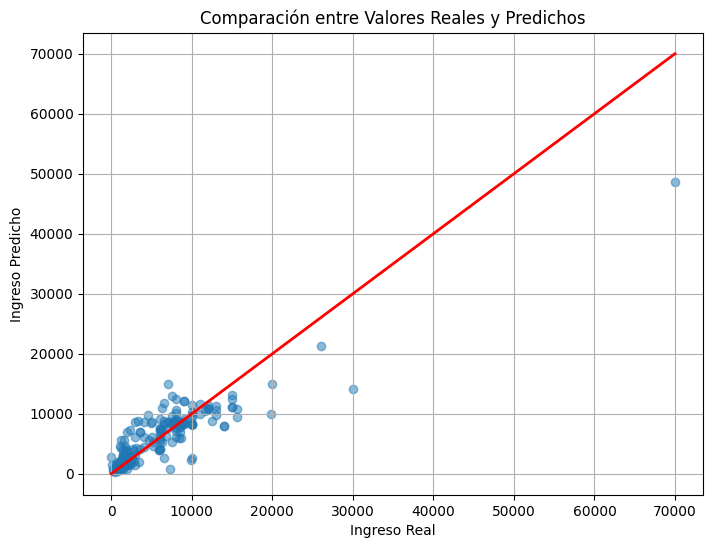

In [ ]:
# Gráfico de comparación entre valores reales y predichos
plt.figure(figsize=(8,6))

# Gráfico de dispersión
plt.scatter(y_test, y_pred, alpha=0.5)

# Línea ideal (Predicción = Valor Real)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.title("Comparación entre Valores Reales y Predichos")
plt.xlabel("Ingreso Real")
plt.ylabel("Ingreso Predicho")

plt.grid(True)

plt.show()

In [ ]:
# Obtener la importancia de cada variable
importancias = modelo_rf.feature_importances_

# Crear un DataFrame con las importancias
variables = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": importancias
})

# Ordenar de mayor a menor importancia
variables = variables.sort_values(
    by="Importancia",
    ascending=False
)

# Mostrar las 10 variables más importantes
variables.head(10)

,Variable,Importancia
17,C366,0.345769
4,C208,0.196101
8,C317,0.088171
9,C318_T,0.078256
5,C310,0.073564
10,whoraT,0.072102
13,SEGURO1,0.037903
25,C377,0.036037
3,C207,0.014902
7,C312,0.010888


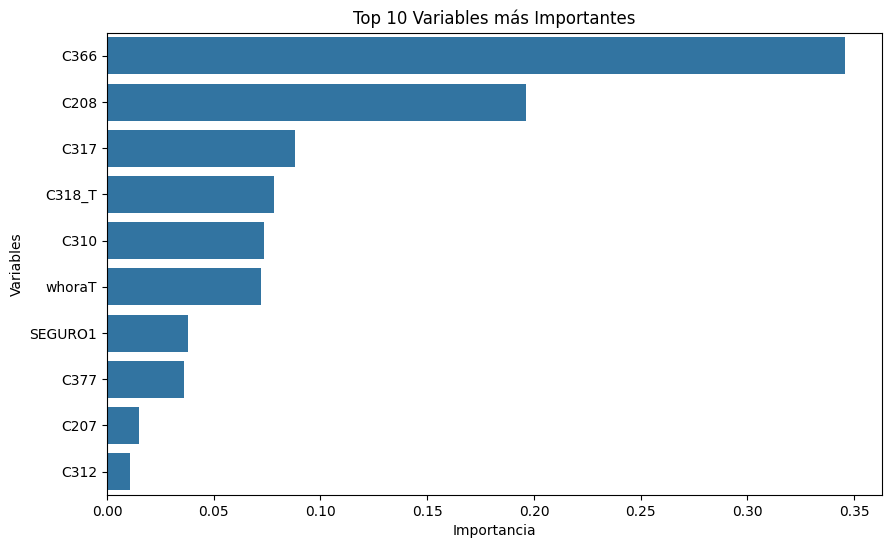

In [ ]:
# Gráfico de importancia de variables
plt.figure(figsize=(10,6))

sns.barplot(
    data=variables.head(10),
    x="Importancia",
    y="Variable"
)

plt.title("Top 10 Variables más Importantes")

plt.xlabel("Importancia")

plt.ylabel("Variables")

plt.show()

##<font color="#07F0DB">9.- Matriz de Confusión</font>

In [ ]:
# Convertir los ingresos reales en tres categorías:
# Bajo, Medio y Alto utilizando terciles.

y_test_cat = pd.qcut(
    y_test,
    q=3,
    labels=["Bajo", "Medio", "Alto"]
)

# Convertir las predicciones en las mismas categorías
y_pred_cat = pd.qcut(
    y_pred,
    q=3,
    labels=["Bajo", "Medio", "Alto"]
)

print("Conversión de ingresos a categorías realizada correctamente.")

Conversión de ingresos a categorías realizada correctamente.


In [ ]:
# Importar librerías para matriz
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Construcción de la matriz de confusión
matriz = confusion_matrix(
    y_test_cat,
    y_pred_cat
)

print(matriz)

[[52  1 13]
 [ 0 49 17]
 [14 16 35]]


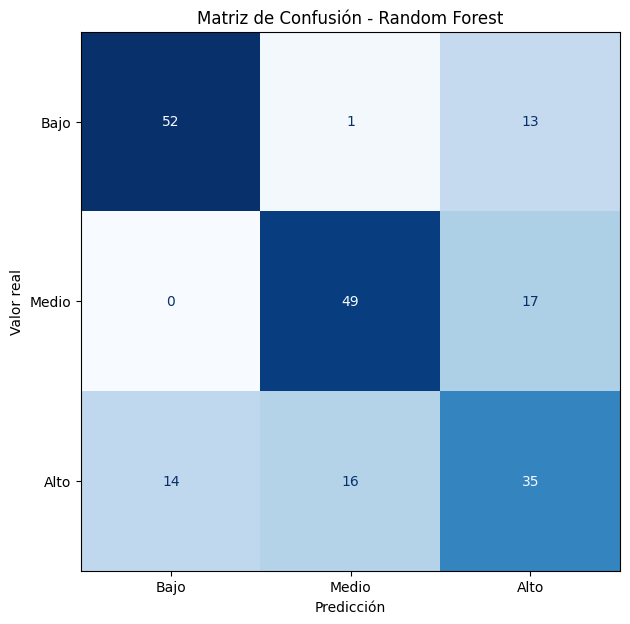

In [ ]:
# Visualización de la matriz de confusión
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Bajo","Medio","Alto"]
)

fig, ax = plt.subplots(figsize=(7,7))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [ ]:
# Resumen del modelo
print("============== RESUMEN ==============")
print(f"Número de registros: {len(entrenamiento)}")
print(f"Número de variables: {X.shape[1]}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

============== RESUMEN ==============
Número de registros: 981
Número de variables: 26
MAE: 1853.59
RMSE: 3106.37
R²: 0.7835


In [ ]:
# Conclusiones

print("CONCLUSIONES DEL MODELO")
print("- El modelo Random Forest logró predecir el ingreso total de las personas utilizando 26 variables socioeconómicas.")
print("- Se obtuvo un coeficiente de determinación (R²) de 0.7835, lo que indica que el modelo explica aproximadamente el 78.35% de la variabilidad del ingreso.")
print("- La matriz de confusión muestra un mejor desempeño en las categorías de ingreso Bajo y Medio, mientras que la categoría Alto presenta una mayor dificultad de clasificación.")
print("- En conjunto, el modelo presenta un desempeño aceptable para apoyar la predicción de ingresos y puede utilizarse como base para la implementación de una interfaz web.")

CONCLUSIONES DEL MODELO
- El modelo Random Forest logró predecir el ingreso total de las personas utilizando 26 variables socioeconómicas.
- Se obtuvo un coeficiente de determinación (R²) de 0.7835, lo que indica que el modelo explica aproximadamente el 78.35% de la variabilidad del ingreso.
- La matriz de confusión muestra un mejor desempeño en las categorías de ingreso Bajo y Medio, mientras que la categoría Alto presenta una mayor dificultad de clasificación.
- En conjunto, el modelo presenta un desempeño aceptable para apoyar la predicción de ingresos y puede utilizarse como base para la implementación de una interfaz web.
